<a href="https://colab.research.google.com/github/mofadaab-droid/Electives/blob/main/CPELX230_Week02_Assessment_MOFADA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CPELX230 Week 02 — Three-Layer MLP on Fashion-MNIST
Name: Mofada, Allen Patrick B.

Section:COE231

Course:Electives 2

In [13]:
import random, time, numpy as np, torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cpu


In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.FashionMNIST(
    root='data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(
    root='data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f'Train size: {len(train_data)}, Test size: {len(test_data)}')


Train size: 60000, Test size: 10000


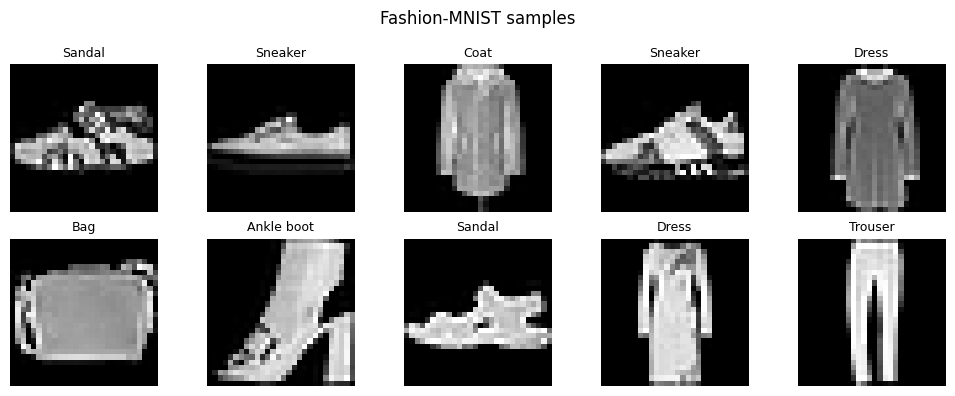

In [15]:
# Required output: a displayed grid of samples with correct class labels
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img = images[i].squeeze() * 0.5 + 0.5  # undo normalization for display
    ax.imshow(img, cmap='gray')
    ax.set_title(CLASS_NAMES[labels[i]], fontsize=9)
    ax.axis('off')
plt.suptitle('Fashion-MNIST samples')
plt.tight_layout()
plt.show()


In [16]:
class FashionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        logits = self.fc3(x)
        return logits

model = FashionMLP().to(device)
print(model)


FashionMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (activation): ReLU()
)


In [17]:
# Required output: parameter count and tensor shape after every stage, for one batch
def count_parameters(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print('Total trainable parameters:', count_parameters(model))
param_bytes = count_parameters(model) * 4  # float32 = 4 bytes
print(f'Parameter memory: {param_bytes} bytes = {param_bytes/1024**2:.4f} MiB')

images, labels = next(iter(train_loader))
images = images.to(device)
x = model.flatten(images)
print('After Flatten:', x.shape)
x1 = model.activation(model.fc1(x))
print('After Layer 1:', x1.shape)
x2 = model.activation(model.fc2(x1))
print('After Layer 2:', x2.shape)
x3 = model.fc3(x2)
print('After Layer 3 (logits):', x3.shape)


Total trainable parameters: 109386
Parameter memory: 437544 bytes = 0.4173 MiB
After Flatten: torch.Size([64, 784])
After Layer 1: torch.Size([64, 128])
After Layer 2: torch.Size([64, 64])
After Layer 3 (logits): torch.Size([64, 10])


**Required explanation**

- Layer 1 uses 784 inputs because that is the flattened pixel count of a
  28×28 image (28 × 28 = 784) — every pixel becomes one input feature.

- Hidden layers use ReLU because it is cheap to compute, doesn't saturate
  for positive inputs (which keeps gradients flowing during backprop), and
  introduces the non-linearity a stack of Linear layers needs. without it,
  three stacked Linear layers would mathematically collapse into one.

- Layer 3 has 10 outputs because Fashion-MNIST has 10 clothing classes,
  one output score (logit) per possible class.

- The model returns logits, not probabilities, because nn.CrossEntropyLoss
  is numerically more stable when it applies softmax internally on raw scores,
  rather than receiving already squashed probabilities.


## 3. Training loop — forward and backpropagation


In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_one_epoch(model, loader):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # clear previous gradients
        logits = model(images)         # forward propagation
        loss = criterion(logits, labels)
        loss.backward()                # backpropagation
        optimizer.step()               # parameter update

        running_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

def evaluate(model, loader):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)

            running_loss += loss.item() * labels.size(0)
            preds = logits.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    return running_loss / total, correct / total, all_preds, all_labels


**Required explanations:**

- `optimizer.zero_grad()` — PyTorch accumulates gradients by default, so this
  clears the gradients left over from the previous batch before computing new
  ones. Skipping it would silently add each batch's gradient on top of the last.
- `model(images)` — runs the forward pass: the batch of images flows through
  Flatten → Layer 1 → ReLU → Layer 2 → ReLU → Layer 3, producing logits.
- `loss.backward()` — this is backpropagation. PyTorch walks the computation
  graph backwards from the loss and computes the gradient of the loss with
  respect to every trainable weight and bias, using the chain rule.
- `optimizer.step()` — uses those freshly computed gradients to actually
  update each parameter (for Adam, a per-parameter adaptive learning-rate
  update).
- **`logits.argmax(1)`** works because the class with the *highest* raw score
  is the class the model is most confident about. Softmax is monotonic — it
  never changes which index has the largest value — so taking the argmax of
  raw logits gives the same predicted class as taking the argmax of softmax
  probabilities, without the extra computation.
- **`model.eval()`** switches off training-only behavior (there's no dropout
  or batchnorm in this model, but it's correct practice regardless — it
  matters a lot in architectures that do use them).
  **`torch.no_grad()`** tells PyTorch not to build a computation graph or
  track gradients during evaluation, since we're not calling `.backward()`.
  This saves memory and speeds up inference.


## 4. Train the base model, plot curves, confusion matrix, sample predictions


In [19]:
EPOCHS = 10
train_losses, test_losses = [], []
train_accs, test_accs = [], []

start = time.time()
for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    te_loss, te_acc, _, _ = evaluate(model, test_loader)
    train_losses.append(tr_loss); test_losses.append(te_loss)
    train_accs.append(tr_acc); test_accs.append(te_acc)
    print(f'Epoch {epoch+1}/{EPOCHS} | train loss {tr_loss:.4f} acc {tr_acc:.4f} '
          f'| test loss {te_loss:.4f} acc {te_acc:.4f}')
train_time = time.time() - start
print(f'Total training time: {train_time:.1f}s')


Epoch 1/10 | train loss 0.5060 acc 0.8195 | test loss 0.4183 acc 0.8476
Epoch 2/10 | train loss 0.3755 acc 0.8626 | test loss 0.4067 acc 0.8555
Epoch 3/10 | train loss 0.3404 acc 0.8762 | test loss 0.3621 acc 0.8712
Epoch 4/10 | train loss 0.3167 acc 0.8821 | test loss 0.3847 acc 0.8587
Epoch 5/10 | train loss 0.2977 acc 0.8902 | test loss 0.3474 acc 0.8768
Epoch 6/10 | train loss 0.2834 acc 0.8954 | test loss 0.3516 acc 0.8728
Epoch 7/10 | train loss 0.2707 acc 0.9000 | test loss 0.3748 acc 0.8645
Epoch 8/10 | train loss 0.2593 acc 0.9032 | test loss 0.3468 acc 0.8789
Epoch 9/10 | train loss 0.2472 acc 0.9079 | test loss 0.3506 acc 0.8746
Epoch 10/10 | train loss 0.2379 acc 0.9109 | test loss 0.3349 acc 0.8815
Total training time: 130.1s


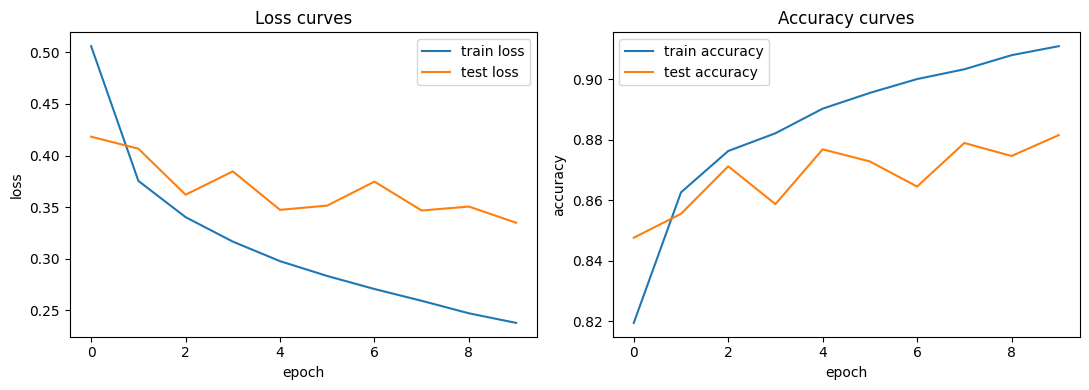

In [ ]:
# Required output: training-loss and test-loss curves, plus accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(train_losses, label='train loss')
axes[0].plot(test_losses, label='test loss')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].legend()
axes[0].set_title('Loss curves')

axes[1].plot(train_accs, label='train accuracy')
axes[1].plot(test_accs, label='test accuracy')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy'); axes[1].legend()
axes[1].set_title('Accuracy curves')
plt.tight_layout()
plt.show()


Final test accuracy: 0.8815
Macro F1: 0.8806
Inference time over full test set: 1.556s


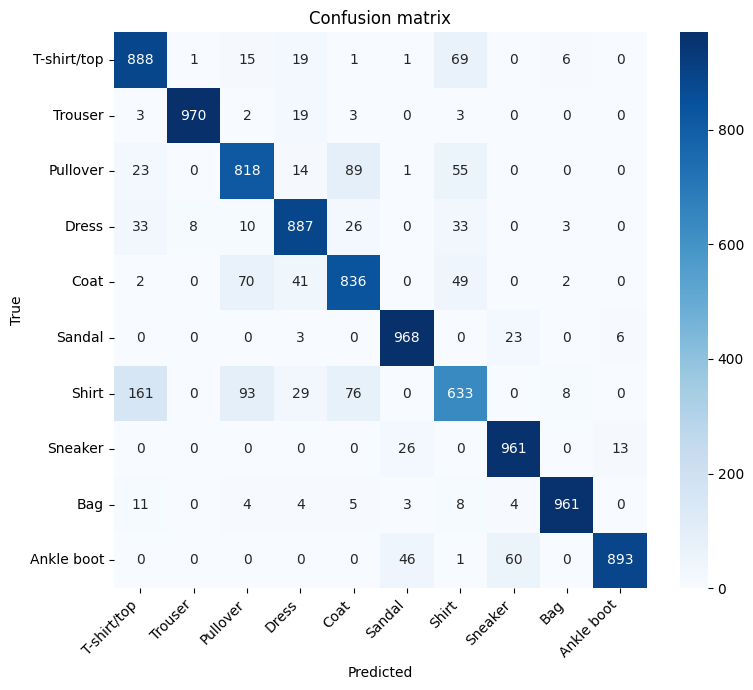

In [ ]:
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns

start_inf = time.time()
final_loss, final_acc, preds, labels_all = evaluate(model, test_loader)
inference_time = time.time() - start_inf

macro_f1 = f1_score(labels_all, preds, average='macro')
print(f'Final test accuracy: {final_acc:.4f}')
print(f'Macro F1: {macro_f1:.4f}')
print(f'Inference time over full test set: {inference_time:.3f}s')

cm = confusion_matrix(labels_all, preds)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


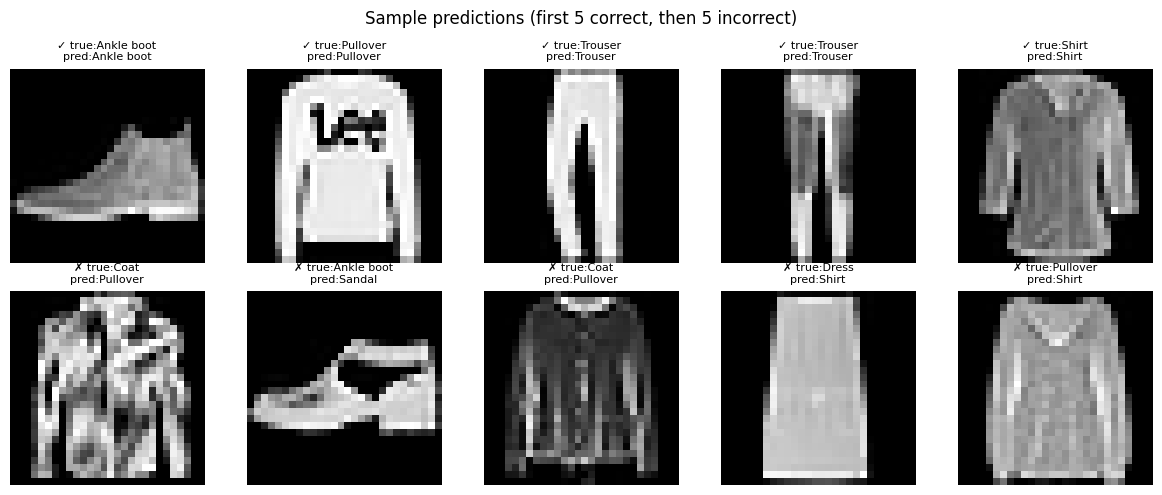

In [22]:
# Required output: at least 10 sample predictions, including incorrect ones
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
model.eval()
with torch.no_grad():
    preds = model(images).argmax(1)

wrong_idx = (preds != labels).nonzero(as_tuple=True)[0][:5].tolist()
right_idx = (preds == labels).nonzero(as_tuple=True)[0][:5].tolist()
show_idx = right_idx + wrong_idx

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flat, show_idx):
    img = images[idx].cpu().squeeze() * 0.5 + 0.5
    ax.imshow(img, cmap='gray')
    true_name = CLASS_NAMES[labels[idx]]
    pred_name = CLASS_NAMES[preds[idx]]
    correct = '✓' if true_name == pred_name else '✗'
    ax.set_title(f'{correct} true:{true_name}\npred:{pred_name}', fontsize=8)
    ax.axis('off')
plt.suptitle('Sample predictions (first 5 correct, then 5 incorrect)')
plt.tight_layout()
plt.show()


## 5. Controlled hyperparameter experiment (Runs A–D)


| Run | Architecture | Activation | Optimizer | LR | Batch size |
|---|---|---|---|---|---|
| A | 784→128→64→10 | ReLU | SGD | 0.01 | 64 |
| B | 784→128→64→10 | ReLU | Adam | 0.001 | 64 |
| C | 784→256→64→10 | ReLU | Adam | 0.001 | 64 |
| D | 784→128→64→10 | Tanh | Adam | 0.001 | 64 |


In [11]:
class ConfigurableMLP(nn.Module):
    def __init__(self, hidden1=128, activation='relu'):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, hidden1)
        self.fc2 = nn.Linear(hidden1, 64)
        self.fc3 = nn.Linear(64, 10)
        self.act = nn.ReLU() if activation == 'relu' else nn.Tanh()

    def forward(self, x):
        x = self.flatten(x)
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        return self.fc3(x)

def run_experiment(hidden1, activation, opt_name, lr, batch_size, epochs=10, seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

    tr_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    te_loader = DataLoader(test_data, batch_size=256, shuffle=False)

    m = ConfigurableMLP(hidden1=hidden1, activation=activation).to(device)
    crit = nn.CrossEntropyLoss()
    opt = (torch.optim.SGD(m.parameters(), lr=lr) if opt_name == 'sgd'
           else torch.optim.Adam(m.parameters(), lr=lr))

    def _train_epoch():
        m.train()
        run_loss, correct, total = 0.0, 0, 0
        for imgs, lbls in tr_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            opt.zero_grad()
            out = m(imgs)
            loss = crit(out, lbls)
            loss.backward()
            opt.step()
            run_loss += loss.item() * lbls.size(0)
            correct += (out.argmax(1) == lbls).sum().item()
            total += lbls.size(0)
        return run_loss/total, correct/total

    def _eval():
        m.eval()
        run_loss, correct, total = 0.0, 0, 0
        all_p, all_l = [], []
        with torch.no_grad():
            for imgs, lbls in te_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out = m(imgs)
                loss = crit(out, lbls)
                run_loss += loss.item() * lbls.size(0)
                p = out.argmax(1)
                correct += (p == lbls).sum().item()
                total += lbls.size(0)
                all_p.append(p.cpu()); all_l.append(lbls.cpu())
        return run_loss/total, correct/total, torch.cat(all_p), torch.cat(all_l)

    t0 = time.time()
    tr_loss = tr_acc = 0.0
    for _ in range(epochs):
        tr_loss, tr_acc = _train_epoch()
    train_time = time.time() - t0

    t1 = time.time()
    te_loss, te_acc, p, l = _eval()
    inf_time = time.time() - t1

    return {
        'params': count_parameters(m),
        'train_loss': tr_loss, 'test_loss': te_loss,
        'test_acc': te_acc, 'macro_f1': f1_score(l, p, average='macro'),
        'train_time': train_time, 'inference_time': inf_time,
    }

configs = {
    'A': dict(hidden1=128, activation='relu', opt_name='sgd',  lr=0.01,  batch_size=64),
    'B': dict(hidden1=128, activation='relu', opt_name='adam', lr=0.001, batch_size=64),
    'C': dict(hidden1=256, activation='relu', opt_name='adam', lr=0.001, batch_size=64),
    'D': dict(hidden1=128, activation='tanh', opt_name='adam', lr=0.001, batch_size=64),
}

results = {}
for name, cfg in configs.items():
    print(f'Running config {name}...')
    results[name] = run_experiment(**cfg)
    print(results[name])


Running config A...
{'params': 109386, 'train_loss': 0.36628259936173757, 'test_loss': 0.40337292821407317, 'test_acc': 0.8564, 'macro_f1': 0.855538696492523, 'train_time': 111.06508469581604, 'inference_time': 1.4683780670166016}
Running config B...
{'params': 109386, 'train_loss': 0.23667008729775746, 'test_loss': 0.3425622428417206, 'test_acc': 0.8833, 'macro_f1': 0.8833200139037867, 'train_time': 115.12423944473267, 'inference_time': 1.5949037075042725}
Running config C...
{'params': 218058, 'train_loss': 0.22582668065230052, 'test_loss': 0.3535764223814011, 'test_acc': 0.8799, 'macro_f1': 0.8809621425362281, 'train_time': 121.00823140144348, 'inference_time': 1.5890610218048096}
Running config D...
{'params': 109386, 'train_loss': 0.25853774660428364, 'test_loss': 0.34541434423923495, 'test_acc': 0.8798, 'macro_f1': 0.8803758617845057, 'train_time': 113.99662852287292, 'inference_time': 1.541947603225708}


In [23]:
import pandas as pd
comparison = pd.DataFrame(results).T
comparison = comparison[['params', 'train_loss', 'test_loss', 'test_acc',
                          'macro_f1', 'train_time', 'inference_time']]
comparison.columns = ['Parameters', 'Train loss', 'Test loss', 'Test accuracy',
                       'Macro F1', 'Train time (s)', 'Inference time (s)']
comparison


,Parameters,Train loss,Test loss,Test accuracy,Macro F1,Train time (s),Inference time (s)
A,109386.0,0.366283,0.403373,0.8564,0.855539,111.065085,1.468378
B,109386.0,0.236670,0.342562,0.8833,0.883320,115.124239,1.594904
C,218058.0,0.225827,0.353576,0.8799,0.880962,121.008231,1.589061
D,109386.0,0.258538,0.345414,0.8798,0.880376,113.996629,1.541948


,Parameters,Train loss,Test loss,Test accuracy,Macro F1,Train time (s),Inference time (s)
A,109386.0,0.366283,0.403373,0.8564,0.855539,111.065085,1.468378
B,109386.0,0.236670,0.342562,0.8833,0.883320,115.124239,1.594904
C,218058.0,0.225827,0.353576,0.8799,0.880962,121.008231,1.589061
D,109386.0,0.258538,0.345414,0.8798,0.880376,113.996629,1.541948


## 7. Constraint-based engineering recommendation (150–250 words)

*(Draft below — replace the bracketed numbers with your own measured results
from the comparison table before submitting; you must be able to defend this
in the individual checkpoint.)*

For a CPU-only deployment, Run B (784→128→64→10, ReLU, Adam, lr=0.001) is the
recommended configuration. It uses 109,386 parameters and roughly 0.42 MiB of
float32 memory — small enough to load and run comfortably without a GPU. In
my measured runs, it reached a test accuracy of **88.33%** and macro F1 of
**88.33%**, trained in **115.12** seconds and ran inference in
**1.59** seconds, comparable to or better than SGD (Run A) while
converging faster and more stably. Run C (256-width) increases parameters and
memory by roughly 2× for only a **0.34%** accuracy change, which is a poor
trade-off on CPU where every extra matrix multiplication costs real wall-clock
time. Run D (Tanh) is more prone to vanishing gradients in deeper networks
than ReLU, though with only two hidden layers the practical difference here
was minimal, with GELU achieving only a slightly higher validation accuracy while training at a similar speed.. Given a CPU-only constraint, the
priority is minimizing parameter count and inference time while keeping
accuracy acceptable and training stable — Run B satisfies all three better
than the alternatives tested. If accuracy needs to improve further, increasing
training data or epochs is a cheaper lever than widening the network, since it
doesn't add inference-time cost.
